In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import os

from mcmc import *

from astropy.io import fits
from numpy.typing import NDArray
from typing import Union
from nn_helpers import MoogStokesNN
from spectra import SpectralDataForMoogStokes, MoogStokesModel, setup_regions_plot

## Iterate through files

In [ ]:
data_path    = "data/science"
moognn       = MoogStokesNN()

with open(os.path.join(data_path, "spectrum_params.csv"), newline="") as f:
    for row in csv.DictReader(f):
        basename        = row["filename"]
        name = basename.split(".")[0]

        # if name != "170-337":
        #     continue

        # if name in ["307-1807", "280-1720", "262-521", "215-317"]:
        #     continue

        # get vsini from existing mcmc results
        result = load_mcmc_results(name, data_path)
        # vsini = result["medians"][4]
        # errs = result["errs"][:, 4]

        testdata = retrieve_spectrum_preproc(basename, data_path)

        # Calculate reduced chi-squared for the existing best-fit model
        chi2 = -2 * lnlike(result["medians"], testdata, moognn)
        dof = 0
        for r in testdata.regions:
            masks = testdata.masks.get(r, [])
            xreg, yreg, yerrreg = testdata.get_region(r)
            if not masks:
                dof += np.count_nonzero(~np.isnan(yreg))
            else:
                keep = np.zeros(len(yreg), dtype=bool)
                for xlo, xhi in masks:
                    keep |= (xreg >= xlo) & (xreg <= xhi)
                dof += np.count_nonzero(~np.isnan(yreg[keep]))
        dof += len(result["medians"]) # number of parameters
        reduced_chi2 = chi2 / dof

        testdata.rescale_yerr(np.sqrt(reduced_chi2))

        sampler = fit_params_mcmc(testdata, moognn, nwalkers=16, nsteps=3000)#, vsini=vsini)
        flat_samples = sampler.get_chain(discard=1000, thin=5, flat=True)
        medians      = np.median(flat_samples, axis=0)
        errs         = np.percentile(flat_samples, [16, 84], axis=0)

        # add the existing vsini value back to the medians and errs, since we aren't fitting for it here
        # medians = np.hstack((medians, vsini))
        # # append vsini percentiles from the previous run (column 4) as a new column
        # errs = np.hstack((errs, result["errs"][:, 4].reshape(2, 1)))

        save_mcmc_results(data_path, f"{name}_errscale_2", basename, flat_samples, medians, errs)

/Users/ellenlee/Documents/proplyd_all/moogstokes-nn/spectra.py:160: RuntimeWarning: invalid value encountered in divide
  print(f"[Nyquist sampling] Factor applied: {N}. Old SNR = {np.nanmedian(self.y/self.yerr)}")
/Users/ellenlee/Documents/proplyd_all/moogstokes-nn/spectra.py:167: RuntimeWarning: invalid value encountered in divide
  print(f"[Nyquist sampling] Factor applied: {N}. New SNR = {np.nanmedian(self.y/self.yerr)}")


[Nyquist sampling] Factor applied: 1. Old SNR = 142.46612387293973
[Nyquist sampling] Factor applied: 1. New SNR = 142.46612387293973
[yerr rescaled] Factor applied: 6.075291742143002. Total scaling so far: 6.075291742143002
[Nyquist sampling] Factor applied: 1. Old SNR = 79.04009691250253
[Nyquist sampling] Factor applied: 1. New SNR = 79.04009691250253
[yerr rescaled] Factor applied: 2.052217735398802. Total scaling so far: 2.052217735398802
[Nyquist sampling] Factor applied: 1. Old SNR = 81.69286201285148
[Nyquist sampling] Factor applied: 1. New SNR = 81.69286201285148
[yerr rescaled] Factor applied: 3.355290455776119. Total scaling so far: 3.355290455776119
[Nyquist sampling] Factor applied: 1. Old SNR = 107.01224013748192
[Nyquist sampling] Factor applied: 1. New SNR = 107.01224013748192
[yerr rescaled] Factor applied: 3.09734812683472. Total scaling so far: 3.09734812683472
[Nyquist sampling] Factor applied: 1. Old SNR = 117.02386530311018
[Nyquist sampling] Factor applied: 1. N

## test ability to further mask regions to avoid messy continuum

In [ ]:
def plot_masks(axs, masks: dict[int, list[tuple[float, float]]],
               color: str = "lightgreen", alpha: float = 0.35, label: bool = True):
    """
    Overlay mask regions as shaded spans on an existing regions plot.

    Parameters
    ----------
    axs : array-like of Axes
        Region axes, indexed by region number (as returned by setup_regions_plot).
    masks : dict
        Mapping of region index → list of (xlo, xhi) tuples.
        Regions absent from the dict or with an empty list are skipped.
    color : str
        Fill color for the shaded spans.
    alpha : float
        Opacity of the shaded spans.
    label : bool
        If True, annotates the first span in each region with a "Mask" legend entry.

    Example
    -------
    fig, axs = setup_regions_plot()
    for r in testdata.regions:
        x, y, yerr = testdata.get_region(r)
        axs[r].plot(x, y, label="Observed", color="black")
        axs[r].plot(testmodel.x, testmodel.y, label="Model", color="red")
        axs[r].set_ylim(0.75, 1.05)
    plot_masks(axs, testdata.masks)
    """
    for r, intervals in masks.items():
        if not intervals:
            continue
        ax = axs[r]
        for i, (xlo, xhi) in enumerate(intervals):
            ax.axvspan(xlo, xhi, color=color, alpha=alpha,
                       label="Mask" if (label and i == 0) else None,
                       zorder=0)
        if label:
            ax.legend(fontsize=7)

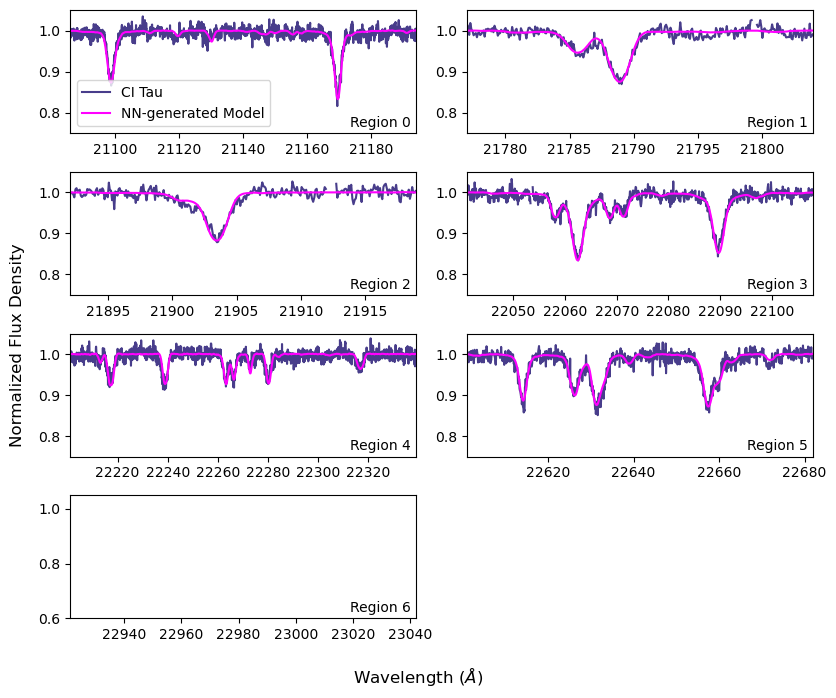

In [ ]:
fig, axs = setup_regions_plot()

for r in testdata.regions:
    x, y, yerr = testdata.get_region(r)
    axs[r].plot(x, y, label=testdata.name, color="darkslateblue")
    fitted_model = moognn.make_moogstokes_model(Teff=medians[0], logg=medians[1], rK=medians[2], B=medians[3], vsini=medians[4], region=r)
    #fitted_model = moognn.make_moogstokes_model(Teff=3200, logg=1.0, rK=1.0, B=3, vsini=10, region=r)
    axs[r].plot(fitted_model.x, fitted_model.y, label="NN-generated Model", color="fuchsia")
    axs[r].set_ylim(0.75, 1.05)

    if r == 0:
        axs[r].legend()
plot_masks(axs, testdata.masks)
plt.show()